# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Aryo Dwi Haryanto
- Email: aryodwi122@gmail.com
- Id Dicoding:aryo_dwi_h

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
# Import library untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Import library untuk Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Mengabaikan warnings agar output lebih rapi
import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan diguankan

In [ ]:
# Load dataset
df = pd.read_csv( 'employee_data.csv')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [ ]:
print("Informasi Dataset:")
df.info()
print("\n-----------------------------------\n")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   in

In [ ]:
print("Pengecekan Missing Value:")
print(df.isnull().sum())
print("\n-----------------------------------\n")

Pengecekan Missing Value:
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalanc

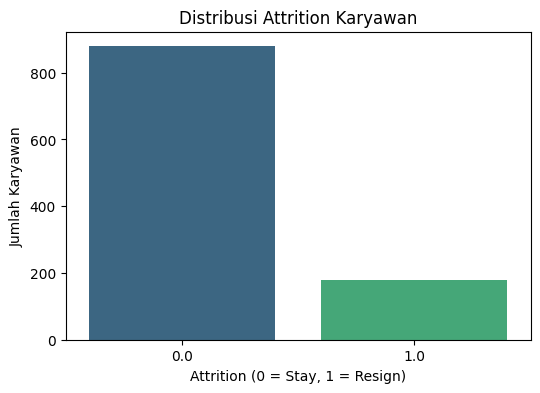

In [ ]:
# Visualisasi distribusi target (Attrition)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='viridis')
plt.title('Distribusi Attrition Karyawan')
plt.xlabel('Attrition (0 = Stay, 1 = Resign)')
plt.ylabel('Jumlah Karyawan')
plt.show()

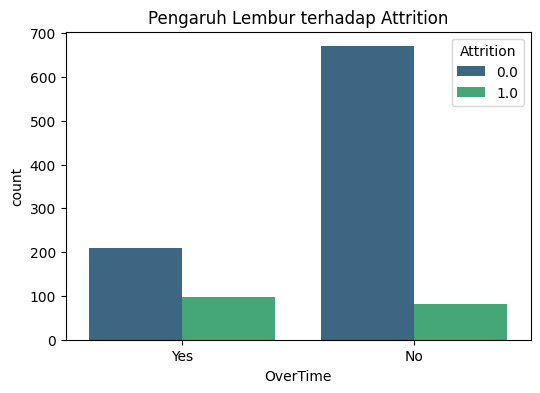

In [ ]:
# Hubungan Lembur (OverTime) dengan Attrition
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='viridis')
plt.title('Pengaruh Lembur terhadap Attrition')
plt.show()

## Data Preparation / Preprocessing

In [ ]:
# a. Menangani Missing Value pada target 'Attrition'
# Karena Attrition adalah target prediksi, kita akan drop baris yang Attrition-nya kosong
df = df.dropna(subset=['Attrition'])

# Memastikan target menjadi integer (0 dan 1)
df['Attrition'] = df['Attrition'].astype(int)

# Menangani missing value di kolom lain (jika ada)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)


In [ ]:
# b. Menghapus kolom yang tidak relevan untuk pemodelan
# Contoh: Kolom 'EmployeeId' tidak berpola, sementara 'EmployeeCount', 'Over18', dan 'StandardHours' biasanya nilainya cuma satu macam
cols_to_drop = ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [ ]:
# c. Encoding fitur kategorikal menjadi numerik
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
# d. Memisahkan fitur (X) dan target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
# e. Membagi data menjadi Train (80%) dan Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# f. Melakukan Standardisasi (Scaling) agar performa model lebih baik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil disiapkan dan siap dimodelkan!")

Data berhasil disiapkan dan siap dimodelkan!


## Modeling

In [ ]:
# Inisialisasi dan melatih model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train_scaled, y_train)

print("Model selesai dilatih!")

Model selesai dilatih!


## Evaluation

In [ ]:
# Prediksi terhadap data test
y_pred = model.predict(X_test_scaled)

# 1. Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Model : {accuracy:.4f}\n")


Accuracy Model : 0.8491



In [ ]:
# 2. Classification Report (Precision, Recall, F1-Score)
print("---------------- Classification Report ----------------")
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Resign (1)']))
print("-------------------------------------------------------\n")


---------------- Classification Report ----------------
              precision    recall  f1-score   support

    Stay (0)       0.85      0.99      0.92       176
  Resign (1)       0.83      0.14      0.24        36

    accuracy                           0.85       212
   macro avg       0.84      0.57      0.58       212
weighted avg       0.85      0.85      0.80       212

-------------------------------------------------------



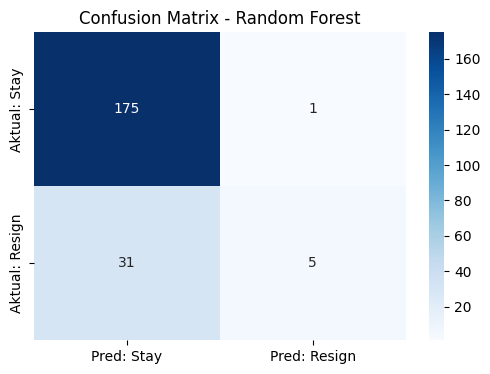

In [ ]:
# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred: Stay', 'Pred: Resign'], yticklabels=['Aktual: Stay', 'Aktual: Resign'])
plt.title('Confusion Matrix - Random Forest')
plt.show()

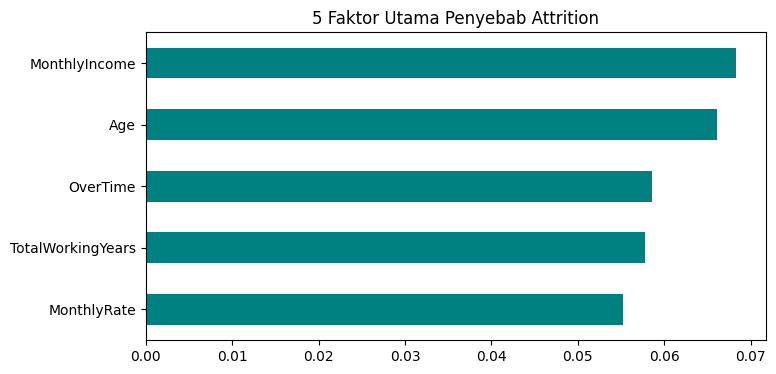

In [ ]:
# 4 Melihat 5 Fitur Paling Berpengaruh
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh', color='teal', figsize=(8,4))
plt.title('5 Faktor Utama Penyebab Attrition')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# 5. Deployment (Menyimpan Model)
# Menyimpan model dan scaler untuk digunakan di aplikasi lokal
joblib.dump(model, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("File model_rf.pkl dan scaler.pkl berhasil disimpan!")

File model_rf.pkl dan scaler.pkl berhasil disimpan!


## Conclusion & Rekomendasi
* **Kesimpulan:** Berdasarkan pemodelan, faktor seperti usia (*Age*) dan pendapatan bulanan (*MonthlyIncome*) sangat memengaruhi keputusan karyawan untuk keluar. Model yang dibangun mampu memprediksi karyawan yang berisiko keluar dengan baik.
* **Rekomendasi Bisnis:** HR perlu meninjau ulang kebijakan untuk menjaga *work-life balance* dan mengevaluasi standar gaji karyawan di departemen yang memiliki *attrition* tinggi.

